# Full Dataset DBScan Clustering Visualisation

## maybe a table makes more sense

### Why is there a none stored with the dbcv value?

How I ran it in the code:  
score = DBCV_score(embeddings_norm, labels)  

According to gemini:  
"The kDBCV library returns a tuple structured as (overall_dbcv_score, individual_cluster_scores) when called."  

Check with the doc:  
"By default, ind_clust_scores is set to False"  

Check in the github code:  
https://github.com/Kaufman-Lab-Columbia/k-DBCV/blob/main/kDBCV/DBCV.py  
"def DBCV_score(  
    X: npt.NDArray[np.float_],  
    labels: npt.NDArray[np.int_],  
    ind_clust_scores: bool = False,  
    mem_cutoff: float = 25.0,  
    batch_mode = False  
) -> Tuple[float, Optional[List[float]]]:"  

"    Returns:  
        Tuple containing:  
            - float: The aggregate DBCV score for the input data.  
            - Optional[List[float]]: The list of individual DBCV scores for each  
              cluster. Only returned if ind_clust_scores is set to True, otherwise  
              returned as None."  

I mean returns sound like it returns a tuple [dbcv, list of cluster dbsv OR None] - I can live with this  

In [7]:
import pandas as pd
import json
from pathlib import Path


dfs = []

for filepath in Path("../results/dbscan_full/").glob("*.json"):
    with open(filepath, "r") as f: 
        clustering_results = json.load(f)

    df = pd.DataFrame.from_dict(clustering_results, orient="index")
    #df = df.drop(columns=["labels"])
    df = df.drop(columns=["dbcv"])
    df["file_name"] = filepath
    
    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)

In [13]:
print(all_results.shape)
print(all_results["model"].value_counts())
print(all_results["min_samples"].value_counts())

(12, 12)
model
bert-base    6
scibert      6
Name: count, dtype: int64
min_samples
100     6
1000    6
Name: count, dtype: int64


In [4]:
all_results.groupby(["model", "layer"])["dbcv"].max()

model      layer   
bert-base  layer_12   -1
scibert    layer_11   -1
Name: dbcv, dtype: int64

In [8]:
all_results["noise_pct"] = round(all_results.n_noise / all_results.n_samples, 4) *100
all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct"]].sort_values(["model", "eps"])

,model,layer,eps,min_samples,n_clusters,noise_pct,largest_cluster_pct
0,bert-base,layer_12,0.13,100,7,48.03,51.806727
6,bert-base,layer_12,0.13,1000,2,75.29,22.787916
1,bert-base,layer_12,0.14,100,3,32.77,67.185240
7,bert-base,layer_12,0.14,1000,3,58.85,38.647409
2,bert-base,layer_12,0.15,100,1,20.95,79.050862
8,bert-base,layer_12,0.15,1000,2,41.94,55.852882
3,scibert,layer_11,0.07,1000,2,49.96,49.623294
9,scibert,layer_11,0.07,100,4,33.66,66.255071
4,scibert,layer_11,0.08,1000,1,30.98,69.019722
10,scibert,layer_11,0.08,100,2,20.10,79.883613


In [9]:
print(all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct"]].sort_values(["model", "eps"]).to_latex(
        index=False,
        column_format="llrrr",
        header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
    ))

\begin{tabular}{llrrr}
\toprule
Model & Layer & Epsilon & MinPts & \#Cluster & Noise \% & Largest Cluster \% \\
\midrule
bert-base & layer_12 & 0.130000 & 100 & 7 & 48.030000 & 51.806727 \\
bert-base & layer_12 & 0.130000 & 1000 & 2 & 75.290000 & 22.787916 \\
bert-base & layer_12 & 0.140000 & 100 & 3 & 32.770000 & 67.185240 \\
bert-base & layer_12 & 0.140000 & 1000 & 3 & 58.850000 & 38.647409 \\
bert-base & layer_12 & 0.150000 & 100 & 1 & 20.950000 & 79.050862 \\
bert-base & layer_12 & 0.150000 & 1000 & 2 & 41.940000 & 55.852882 \\
scibert & layer_11 & 0.070000 & 1000 & 2 & 49.960000 & 49.623294 \\
scibert & layer_11 & 0.070000 & 100 & 4 & 33.660000 & 66.255071 \\
scibert & layer_11 & 0.080000 & 1000 & 1 & 30.980000 & 69.019722 \\
scibert & layer_11 & 0.080000 & 100 & 2 & 20.100000 & 79.883613 \\
scibert & layer_11 & 0.090000 & 1000 & 1 & 17.960000 & 82.037480 \\
scibert & layer_11 & 0.090000 & 100 & 1 & 11.700000 & 88.295956 \\
\bottomrule
\end{tabular}



<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\#'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],


In [4]:
all_results.loc[
        all_results.groupby(["model", "layer"])["dbcv"].idxmax()
    ].sort_values("dbcv", ascending=False)[
        ["model", "layer", "eps", "min_samples", "dbcv"]
        ]

,model,layer,eps,min_samples,dbcv
3,bert-base,layer_12,0.13,100,-1
0,scibert,layer_11,0.07,1000,-1


# FOS vs Cluster Assignemnt

In [1]:
# oa_df
import pandas as pd
import glob
import json

# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

files_meta = glob.glob("../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files_meta)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files_meta:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                record = json.loads(line)

                records.append({
                    "oa_topics": record.get("oa_topics"),
                    "paperId": record.get("paperId")
                })

            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

oa_df = pd.DataFrame(records)

print(oa_df.shape)
print(oa_df.columns)

Found 4 files
(311686, 2)
Index(['oa_topics', 'paperId'], dtype='str')


In [2]:
# get fos
def get_dominant_field(topics):
    if not isinstance(topics, list) or len(topics) == 0:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    field_scores = {}

    for topic in topics:
        field = topic.get("field")
        score = topic.get("score", 0)

        if field is not None:
            field_scores.setdefault(field, []).append(score)

    if not field_scores:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    # Sort fields by their accumulated score
    sorted_fields = sorted(
        field_scores,
        key=lambda field: sum(field_scores[field]),
        reverse=True
    )

    # Dominant field
    dominant_field = sorted_fields[0]
    dominant_scores = field_scores[dominant_field]

    # Second field, if one exists
    if len(sorted_fields) > 1:
        second_field = sorted_fields[1]
        second_scores = field_scores[second_field]
        second_avg_score = sum(second_scores) / len(second_scores)
    else:
        second_field = None
        second_avg_score = None

    return pd.Series({
        "dominant_field": dominant_field,
        "dominant_field_score": sum(dominant_scores),
        "dominant_field_avg_score": sum(dominant_scores) / len(dominant_scores),
        "second_field": second_field,
        "second_field_avg_score": second_avg_score
    })


oa_df[
    [
        "dominant_field",
        "dominant_field_score",
        "dominant_field_avg_score",
        "second_field",
        "second_field_avg_score"
    ]
] = oa_df["oa_topics"].apply(get_dominant_field)

In [43]:
# load mentions

import pandas as pd
import json

pop_file = "../data/mentions/narrative_mentions.jsonl"

records = []

with open(pop_file, "r", encoding="utf-8") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Skipping malformed line in {pop_file}")

mentions_df = pd.DataFrame(records)

print(mentions_df.shape)
print(mentions_df.columns)

mentions_df = mentions_df[['paperId', 'text_type', 'id', 'text_cleaned']] #free up storage

print(mentions_df.shape)
print(mentions_df.columns)

(537645, 15)
Index(['paperId', 'doi', 'oa_id', 'text_type', 'text_cleaned', 'match_type',
       'matched_seq', 'matched_char_start', 'matched_char_end', 'sentence_pos',
       'pos', 'id', 'context_token_ids', 'context_n_tokens',
       'matched_token_indices'],
      dtype='str')
(537645, 4)
Index(['paperId', 'text_type', 'id', 'text_cleaned'], dtype='str')


In [44]:
merged_df = mentions_df.merge(
    oa_df,
    on="paperId",
    how="left"
)

print(oa_df["paperId"].duplicated().sum())

0


In [9]:
all_results#["labels"]

,model,layer,eps,min_samples,n_clusters,n_noise,largest_cluster_size,largest_cluster_pct,runtime_seconds,n_samples,labels,file_name
0,bert-base,layer_12,0.13,100,7,239757,258614,51.806727,14006.189385,499190,"{'103342': 0, '103343': 0, '103344': -1, '1033...",../results/dbscan_full/full_clustering_results...
1,bert-base,layer_12,0.14,100,3,163578,335382,67.185240,14435.214428,499190,"{'103342': 0, '103343': 0, '103344': 0, '10334...",../results/dbscan_full/full_clustering_results...
2,bert-base,layer_12,0.15,100,1,104576,394614,79.050862,14482.384101,499190,"{'103342': 0, '103343': 0, '103344': 0, '10334...",../results/dbscan_full/full_clustering_results...
3,scibert,layer_11,0.07,1000,2,249398,247717,49.623294,14051.404294,499195,"{'103343': -1, '103344': -1, '103345': 0, '103...",../results/dbscan_full/full_clustering_results...
4,scibert,layer_11,0.08,1000,1,154652,344543,69.019722,14035.007494,499195,"{'103343': 0, '103344': -1, '103345': 0, '1033...",../results/dbscan_full/full_clustering_results...
5,scibert,layer_11,0.09,1000,1,89668,409527,82.037480,14027.197365,499195,"{'103343': 0, '103344': -1, '103345': 0, '1033...",../results/dbscan_full/full_clustering_results...
6,bert-base,layer_12,0.13,1000,2,375822,113755,22.787916,12753.228699,499190,"{'103342': 0, '103343': 1, '103344': -1, '1033...",../results/dbscan_full/full_clustering_results...
7,bert-base,layer_12,0.14,1000,3,293770,192924,38.647409,12936.054852,499190,"{'103342': 1, '103343': 0, '103344': -1, '1033...",../results/dbscan_full/full_clustering_results...
8,bert-base,layer_12,0.15,1000,2,209364,278812,55.852882,12972.478520,499190,"{'103342': 1, '103343': 0, '103344': -1, '1033...",../results/dbscan_full/full_clustering_results...
9,scibert,layer_11,0.07,100,4,168009,330742,66.255071,7851.307870,499195,"{'103343': 0, '103344': -1, '103345': 0, '1033...",../results/dbscan_full/full_clustering_results...


In [45]:
best = all_results[(all_results.model == "scibert") & (all_results.min_samples == 100) & (all_results.eps == 0.07)]
best["labels"]

9    {'103343': 0, '103344': -1, '103345': 0, '1033...
Name: labels, dtype: object

In [46]:
labels_df = pd.DataFrame(
    best["labels"].iloc[0].items(),
    columns=["id", "cluster"]
)

labels_df["id"] = labels_df["id"].astype(int)

labels_df.head()

,id,cluster
0,103343,0
1,103344,-1
2,103345,0
3,103346,0
4,103347,-1


In [26]:
type(labels_df.id.iloc[0])

numpy.int64

In [47]:
merged_df_all = merged_df.merge(
    labels_df,
    on="id",
    how="left"
)

In [48]:
merged_df_all.head()

,paperId,text_type,id,text_cleaned,oa_topics,dominant_field,dominant_field_score,dominant_field_avg_score,second_field,second_field_avg_score,cluster
0,0000278bfcd5dfc1d586156ccff16e168f238e83,title,0,reading contemporary black british and african...,"[{'id': 'https://openalex.org/T11717', 'displa...",Arts and Humanities,0.9700,0.97000,NaN,NaN,-1.0
1,0000278bfcd5dfc1d586156ccff16e168f238e83,abstract,1,"in their introduction, wyatt and george expres...","[{'id': 'https://openalex.org/T11717', 'displa...",Arts and Humanities,0.9700,0.97000,NaN,NaN,0.0
2,4aae5a329915daacf79c4354ec5c72d136424348,abstract,2,the authors show how visual culture has been e...,"[{'id': 'https://openalex.org/T13256', 'displa...",Social Sciences,1.8446,0.92230,NaN,NaN,-1.0
3,4aaeb618b4e06b682c54f3db0eace3690b07c01a,title,3,vocabulary diversity in personal narratives pr...,"[{'id': 'https://openalex.org/T10103', 'displa...",Psychology,0.8421,0.42105,Neuroscience,0.0823,-1.0
4,4aaeb618b4e06b682c54f3db0eace3690b07c01a,abstract,4,introduction: this study examines whether ther...,"[{'id': 'https://openalex.org/T10103', 'displa...",Psychology,0.8421,0.42105,Neuroscience,0.0823,0.0


In [30]:
merged_df_all.columns

Index(['paperId', 'text_type', 'id', 'oa_topics', 'dominant_field',
       'dominant_field_score', 'dominant_field_avg_score', 'second_field',
       'second_field_avg_score', 'cluster'],
      dtype='str')

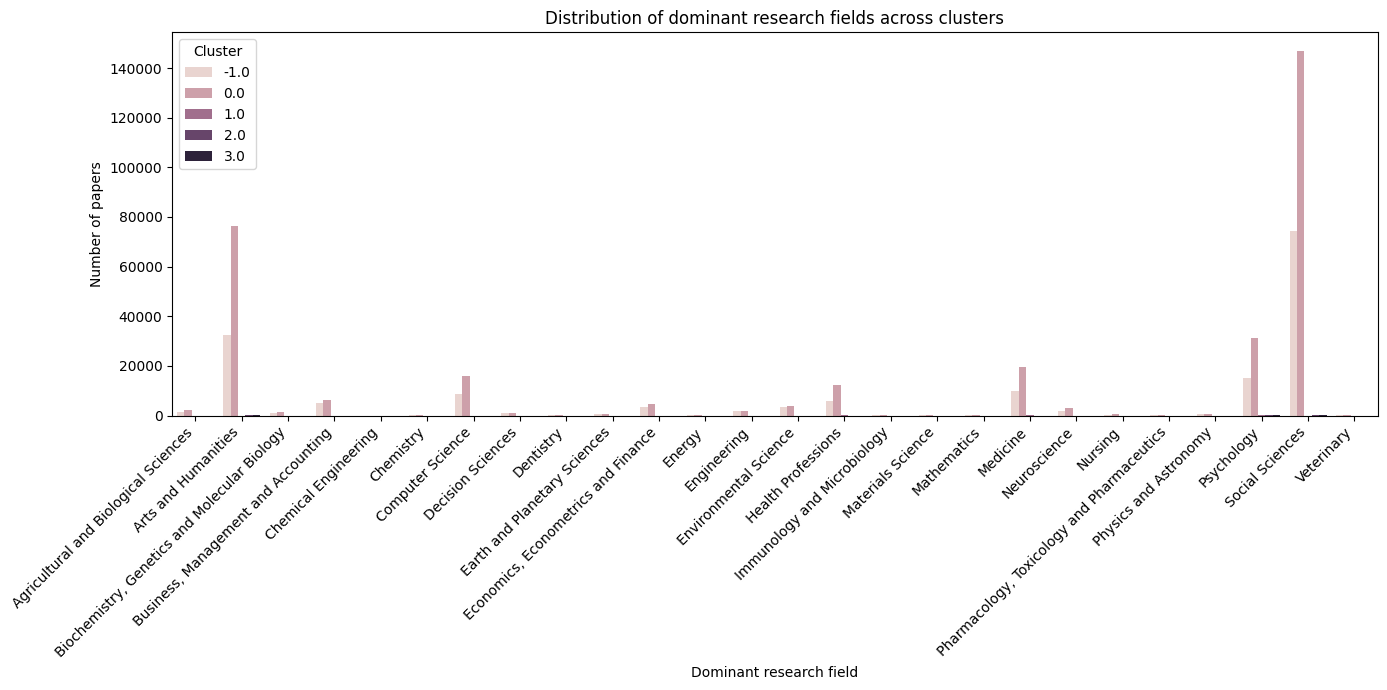

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count papers per field and cluster
counts = (
    merged_df_all
    .groupby(["dominant_field", "cluster"])
    .size()
    .reset_index(name="count")
)

# Plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=counts,
    x="dominant_field",
    y="count",
    hue="cluster",
)

plt.xlabel("Dominant research field")
plt.ylabel("Number of papers")
plt.title("Distribution of dominant research fields across clusters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

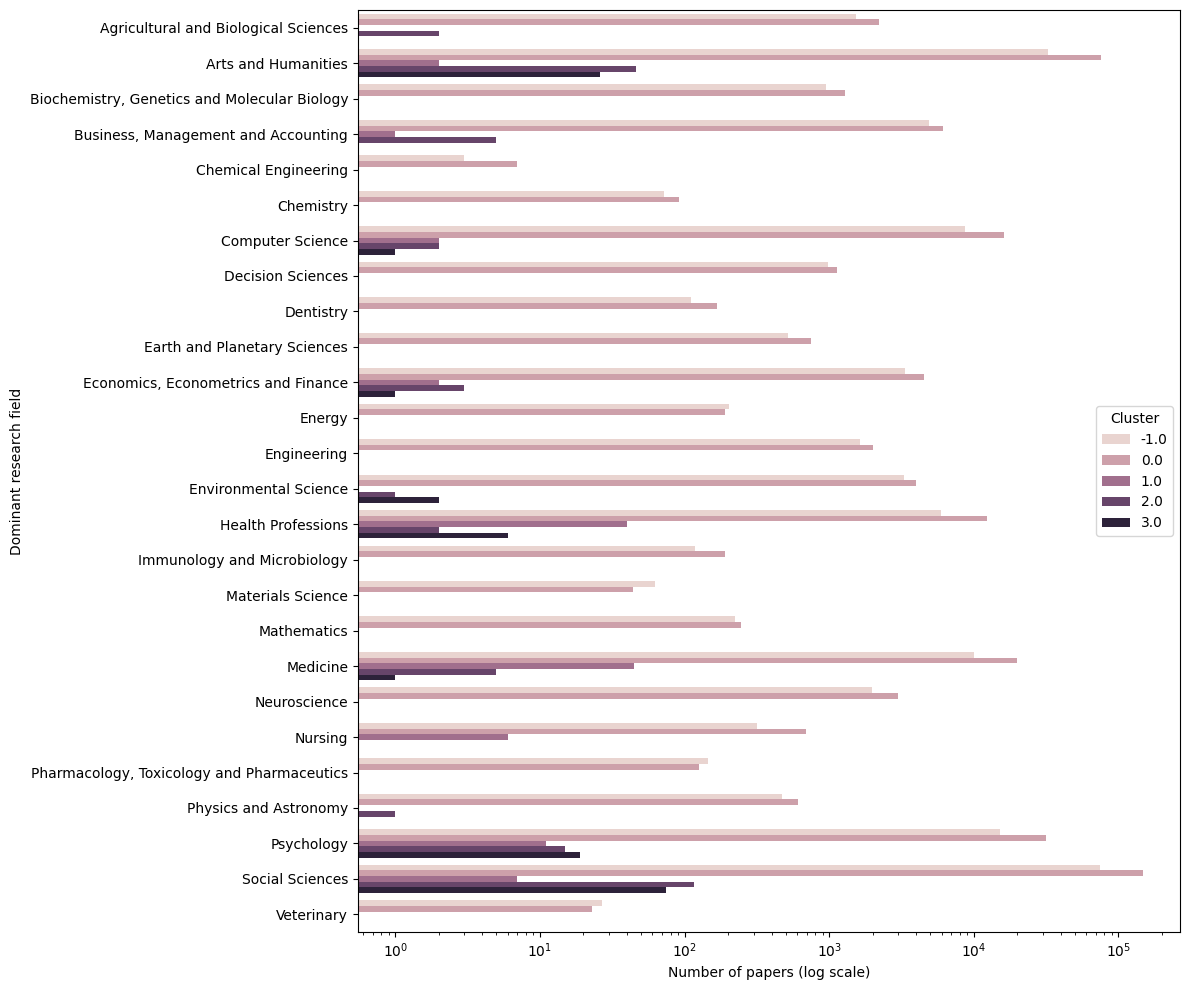

In [35]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=counts,
    x="count",
    y="dominant_field",
    hue="cluster",
)

plt.xscale("log")

plt.xlabel("Number of papers (log scale)")
plt.ylabel("Dominant research field")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

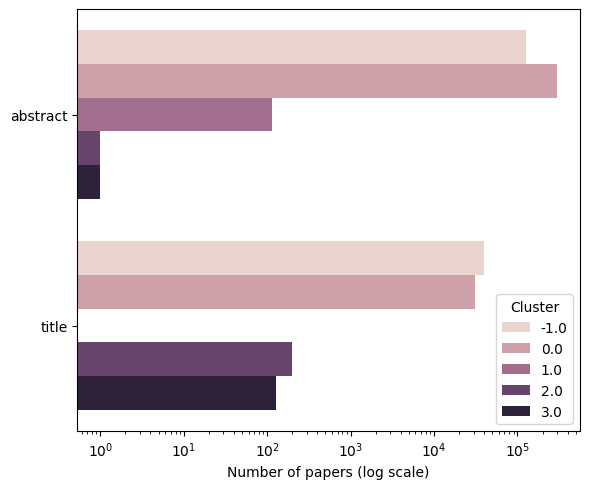

In [40]:
# Count papers per field and cluster
counts = (
    merged_df_all
    .groupby(["text_type", "cluster"])
    .size()
    .reset_index(name="count")
)
plt.figure(figsize=(6, 5))

sns.barplot(
    data=counts,
    x="count",
    y="text_type",
    hue="cluster",
)

plt.xscale("log")

plt.xlabel("Number of papers (log scale)")
plt.ylabel("")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

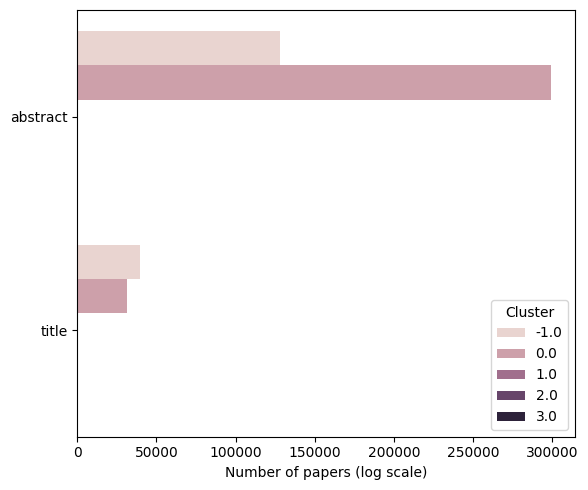

In [41]:
# Count papers per field and cluster
counts = (
    merged_df_all
    .groupby(["text_type", "cluster"])
    .size()
    .reset_index(name="count")
)
plt.figure(figsize=(6, 5))

sns.barplot(
    data=counts,
    x="count",
    y="text_type",
    hue="cluster",
)

#plt.xscale("log")

plt.xlabel("Number of papers (log scale)")
plt.ylabel("")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    top_indices = scores.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (terms[i], scores[i])
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, score in ngrams:
        print(f"{ngram:40s} {score:.4f}")


Cluster -1.0
narrative                                0.0242
narratives                               0.0204
study                                    0.0061
analysis                                 0.0052
research                                 0.0050
social                                   0.0049
based                                    0.0043
data                                     0.0039
new                                      0.0039
article                                  0.0038

Cluster 0.0
narrative                                0.0235
narratives                               0.0185
study                                    0.0070
analysis                                 0.0070
research                                 0.0055
article                                  0.0048
using                                    0.0043
data                                     0.0043
approach                                 0.0042
social                                   0.0041

Cluster 1.0


In [50]:
top_ngrams_df = pd.DataFrame(
    [
        {
            "cluster": cluster,
            "ngram": ngram,
            "tfidf": score
        }
        for cluster, ngrams in top_ngrams.items()
        for ngram, score in ngrams
    ]
)

top_ngrams_df

,cluster,ngram,tfidf
0,-1.0,narrative,0.024184
1,-1.0,narratives,0.020379
2,-1.0,study,0.006110
3,-1.0,analysis,0.005202
4,-1.0,research,0.005044
5,-1.0,social,0.004916
6,-1.0,based,0.004316
7,-1.0,data,0.003883
8,-1.0,new,0.003861
9,-1.0,article,0.003757


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        ngram_range=(2, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    # Keep only n-grams containing "narrative" or "narratives"
    mask = [
        any(word in {"narrative", "narratives"} for word in term.split())
        for term in terms
    ]

    filtered_terms = terms[mask]
    filtered_scores = scores[mask]

    # Top 10
    top_indices = filtered_scores.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (filtered_terms[i], filtered_scores[i])
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, score in ngrams:
        print(f"{ngram:40s} {score:.4f}")


Cluster -1.0
historical narrative                     0.0014
counter narratives                       0.0013
counter narrative                        0.0013
historical narratives                    0.0011
narrative analysis                       0.0011
personal narrative                       0.0011
personal narratives                      0.0010
master narrative                         0.0009
media narratives                         0.0008
life narratives                          0.0008

Cluster 0.0
narrative analysis                       0.0031
narrative inquiry                        0.0030
narrative structure                      0.0020
narrative approach                       0.0020
narrative text                           0.0019
using narrative                          0.0016
historical narratives                    0.0015
historical narrative                     0.0013
personal narratives                      0.0013
narrative form                           0.0012

Cluster 1.0


In [53]:
merged_df_all[merged_df_all.cluster == 1.0].text_cleaned

1101      selection and appraisal of documents were base...
2081      we employed pawson and tilley’s realist review...
6600      methods and analysis this realist review will ...
9724      findings will be presented in accordance with ...
17439     methods and analysis the protocol has been reg...
                                ...                        
514200    results will be written according to the rames...
517088    the results will be published in accordance wi...
520077    the review follows the guidelines presented by...
522253    methods this was a realist review reported fol...
534898    following realist and meta-narrative evidence ...
Name: text_cleaned, Length: 116, dtype: str

In [54]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = CountVectorizer(
        ngram_range=(2, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    terms = vectorizer.get_feature_names_out()

    # Keep only n-grams containing "narrative" or "narratives"
    mask = [
        any(word in {"narrative", "narratives"} for word in term.split())
        for term in terms
    ]

    filtered_terms = terms[mask]
    filtered_counts = X[:, mask].sum(axis=0).A1

    # Top 10 by actual occurrence count
    top_indices = filtered_counts.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (filtered_terms[i], int(filtered_counts[i]))
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, count in ngrams:
        print(f"{ngram:40s} {count}")


Cluster -1.0
narrative time                           1435
historical narrative                     1298
narrative analysis                       1289
counter narrative                        1193
counter narratives                       1192
historical narratives                    1054
master narrative                         1037
narrative text                           1033
narrative time nero                      1026
non narrative                            1019

Cluster 0.0
narrative analysis                       7559
narrative inquiry                        7319
narrative text                           4786
narrative structure                      4548
narrative approach                       4150
using narrative                          3556
historical narratives                    3089
personal narratives                      2554
narrative texts                          2401
historical narrative                     2370

Cluster 1.0
narrative evidence syntheses            